# Spectroscopic Completeness (f_spec) Analysis for A2199

This notebook analyzes the spectroscopic completeness as a function of magnitude and projected radius for the A2199 cluster.

**f_spec** = fraction of galaxies with spectroscopic redshifts compared to all galaxies (photometric sample)

## Setup and Configuration

Import libraries and set up cosmology (H0=70, ΩM=0.3, ΩΛ=0.7) and plotting parameters.

In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

# 0. Import Data

Load the A2199 master catalog, apply extinction corrections, and identify galaxies with spectroscopic redshifts from Song+2017, SDSS, and NED.

In [2]:
# --- Import cluster redshift catalog and select redshift for A2199
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID'] == 'A2199']['Z'].values[0]

# --- Import galaxy master catalog for A2199 within 35 arcmin
df0 = pd.read_csv('../../DATA/A2199/A2199_mastercat_within35arcmin.csv')

# --- Correct model magnitudes for foreground extinction (for each band)
df0['p_modelmag_u_0'] = df0['p_modelmag_u'] - df0['p_extinction_u']
df0['p_modelmag_g_0'] = df0['p_modelmag_g'] - df0['p_extinction_g']
df0['p_modelmag_r_0'] = df0['p_modelmag_r'] - df0['p_extinction_r']
df0['p_modelmag_i_0'] = df0['p_modelmag_i'] - df0['p_extinction_i']
df0['p_modelmag_z_0'] = df0['p_modelmag_z'] - df0['p_extinction_z']

# --- Correct Petrosian magnitudes for foreground extinction (for each band)
df0['p_petromag_u_0'] = df0['p_petromag_u'] - df0['p_extinction_u']
df0['p_petromag_g_0'] = df0['p_petromag_g'] - df0['p_extinction_g']
df0['p_petromag_r_0'] = df0['p_petromag_r'] - df0['p_extinction_r']
df0['p_petromag_i_0'] = df0['p_petromag_i'] - df0['p_extinction_i']
df0['p_petromag_z_0'] = df0['p_petromag_z'] - df0['p_extinction_z']

# --- Select only galaxies (galaxyflag==1) within 35 arcmin of cluster center
df = df0[(df0['galaxyflag'] == 1) & (df0['p_radgal'] < 35)]

# --- Import Song2017 catalog (z_mmt_z!=-9 selects galaxies with measured redshifts)
df_song = pd.read_csv('../../DATA/A2199/Song2017/z_DATA_8/z_a2199phot21_5DR9_hshwang_35arcmin_Song2017.csv')

df_song = df_song[df_song['z_mmt_z'] != -9]

# --- Create a set of Song2017 SDSS object IDs for quick lookup
song_objids = set(df_song['p_objid'])

# --- Flag galaxies as being present in Song2017, SDSS or NED spectra
# A flag "Y" if any of: 
#   - the z-source is SDSS, or
#   - the z-source is NED, or
#   - the object id is present in Song2017 catalog
# Otherwise, flag as "N"
df['Song2017_Flag'] = df.apply(
    lambda row: (
        'Y'
        if row['z_tot_zsource'] == 'sdss'
        or row['z_tot_zsource'] == 'ned'
        or row['p_objid'] in song_objids
        else 'N'
    ),
    axis=1
)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/55662879.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Song2017_Flag'] = df.apply(


# 1. 1D Spectroscopic Completeness vs Magnitude

Calculate and plot f_spec as a function of r-band magnitude in different radial bins.

<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\p'
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/83070638.py:74: SyntaxWarning: invalid escape sequence '\m'
  ax_bot.set_xlabel('$r_{\mathrm{Petro,0}}$', fontsize=35)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/83070638.py:75: SyntaxWarning: invalid escape sequence '\m'
  ax_bot.set_ylabel('$f_{\mathrm{spec}}$', fontsize=35)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/83070638.py:93: SyntaxWarning: invalid escape sequence '\p'
  ax_bot.text(0.05, 0.05, '$R_{cl}<30^\prime$', transform=ax_bot.transAxes, fontsize=28, ha='left', va='bottom')
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/83070638.py:25: FutureWarn

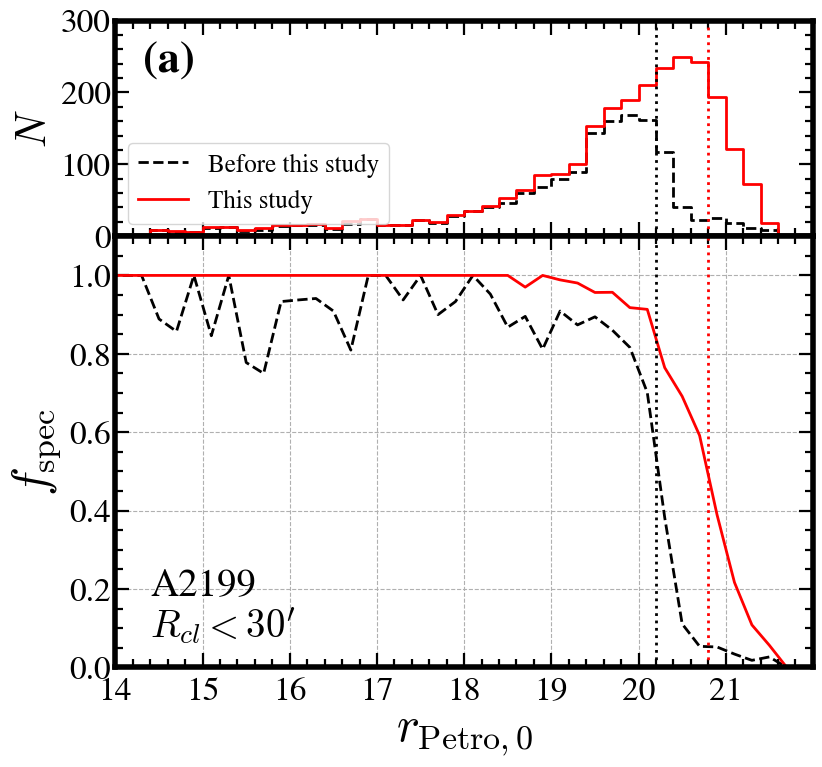

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# --- Replace this with your target cluster ID ---
cluster_id = "A2199"

# Filtered dataset: only Rcl_arcmin < 30
cluster_data = df[df['p_radgal'] < 30]

# Subset with Song2017_Flag == 'Y'
flagged_data = cluster_data[cluster_data['Song2017_Flag'] == 'Y']

# Define bins for p_petromag_r_0
bin_width = 0.2
bin_edges = np.arange(12, 22 + bin_width, bin_width)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ---- Compute metrics for full sample ----
# Total objects per bin
bin_all = pd.cut(cluster_data['p_petromag_r_0'], bins=bin_edges, include_lowest=True)
total_all = bin_all.value_counts(sort=False).values
# Count objects with spec-z (z_tot_z != -9)
non99_all = cluster_data.groupby(bin_all)['z_tot_z'].apply(lambda x: (x != -9.0).sum()).values
# Spectroscopic fraction for full sample
frac_all = non99_all / total_all

# ---- Compute metrics for flagged subset ----
bin_flag = pd.cut(flagged_data['p_petromag_r_0'], bins=bin_edges, include_lowest=True)
non99_flag = flagged_data.groupby(bin_flag)['z_tot_z'].apply(lambda x: (x != -9.0).sum()).values
# Spectroscopic fraction for flagged relative to full total
frac_flag = non99_flag / total_all

# Find thresholds where f_spec > 0.5
threshold_val50_all = next((c for c, f in zip(bin_centers[::-1], frac_all[::-1]) if f > 0.50), None)
threshold_val50_flag = next((c for c, f in zip(bin_centers[::-1], frac_flag[::-1]) if f > 0.50), None)

# ---- Plotting ----
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(15 * 0.6, 12 * 0.7),
    gridspec_kw={'height_ratios': [1.5, 3], 'hspace': 0},
    sharex=True
)


# Upper panel: counts
# "Before this study" (flagged) as black dashed; "This study" (all) as red solid
ax_top.step(bin_centers, non99_flag, where='mid', color='black', linestyle='--', lw=2, label='Before this study')
ax_top.step(bin_centers, non99_all, where='mid', color='red', linestyle='-', lw=2, label='This study')
ax_top.set_ylabel('$N$', fontsize=30)
ax_top.set_ylim(0, 300)
ax_top.tick_params(which='both', top=True, right=True, labelsize=24)
ax_top.xaxis.set_minor_locator(MultipleLocator(0.2))
ax_top.set_yticks([0, 100, 200, 300])
ax_top.legend(loc='lower left', fontsize=18)

# Add annotation "(a)" to the top panel
ax_top.text(
    0.04, 0.90,            # x,y in axis fraction units
    '(a)',                 
    transform=ax_top.transAxes,
    fontsize=32,
    fontweight='bold',
    ha='left',
    va='top'
)

# Lower panel: spectroscopic fraction
ax_bot.plot(bin_centers, frac_flag, '--', color='black', lw=2, label='$f_{spec}$ Before this study')
ax_bot.plot(bin_centers, frac_all, '-', color='red', lw=2, label='$f_{spec}$ This study')
ax_bot.set_xlim(14, 22)
ax_bot.set_xticks(np.arange(14, 22, 1))
ax_bot.set_xlabel('$r_{\mathrm{Petro,0}}$', fontsize=35)
ax_bot.set_ylabel('$f_{\mathrm{spec}}$', fontsize=35)
ax_bot.set_ylim(0, 1.1)
ax_bot.xaxis.set_minor_locator(MultipleLocator(0.2))
ax_bot.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax_bot.grid(which='major', axis='x', linestyle='--', linewidth=0.8)
ax_bot.grid(which='major', axis='y', linestyle='--', linewidth=0.8)
ax_bot.tick_params(which='both', top=True, right=True, labelsize=24)

# Threshold lines for f_spec > 0.5
if threshold_val50_flag is not None:
    ax_top.axvline(threshold_val50_flag+0.5*bin_width, color='black', linestyle=':', linewidth=2)
    ax_bot.axvline(threshold_val50_flag+0.5*bin_width, color='black', linestyle=':', linewidth=2)
if threshold_val50_all is not None:
    ax_top.axvline(threshold_val50_all+0.5*bin_width, color='red', linestyle=':', linewidth=2)
    ax_bot.axvline(threshold_val50_all+0.5*bin_width, color='red', linestyle=':', linewidth=2)

# Annotations
ax_bot.text(0.05, 0.15, cluster_id, transform=ax_bot.transAxes, fontsize=28, ha='left', va='bottom')
ax_bot.text(0.05, 0.05, '$R_{cl}<30^\prime$', transform=ax_bot.transAxes, fontsize=28, ha='left', va='bottom')

# Spine widths
for spine in ax_top.spines.values(): spine.set_linewidth(4)
for spine in ax_bot.spines.values(): spine.set_linewidth(4)


# 2. 2D Spectroscopic Completeness Map

Create a 2D map showing f_spec as a function of both magnitude and projected radius.

**Purpose**: Visualize the combined effect of brightness and distance on spectroscopic completeness using a heatmap/contour plot.

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/3375102956.py:102: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  k = kde.gaussian_kde(kde_data, bw_method=0.15)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/3375102956.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


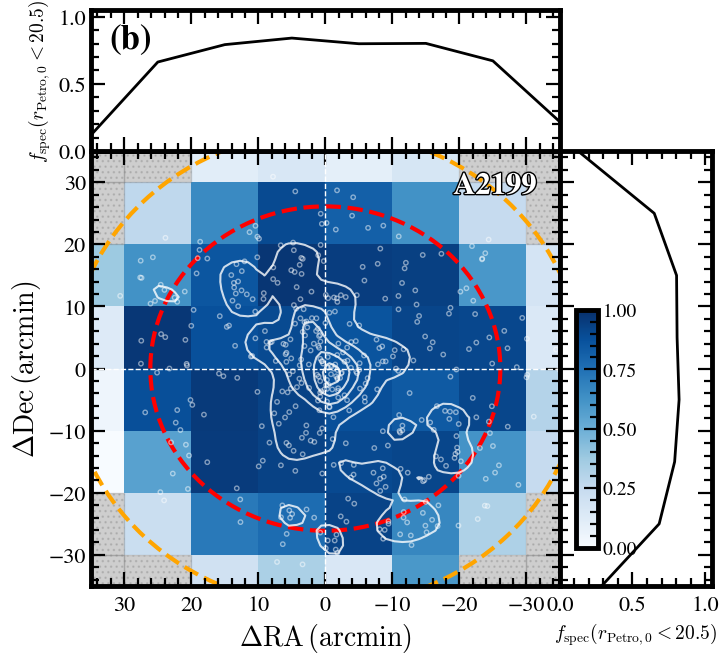

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
from scipy.stats import binned_statistic_2d, binned_statistic
from scipy.stats import kde
import pandas as pd
from matplotlib import gridspec

# Define the specific target cluster ID
TARGET = 'A2199'
bin_width = 10

# Filter magnitude-limited sample
df_speccomp = df[df['p_petromag_r_0'] < 20.5]
df_speccomp_target = df_speccomp

# Cluster coordinates and properties
central_row = hecs_vac_data[hecs_vac_data['CLID'] == TARGET]
central_ra = central_row['RA'].values[0]
central_dec = central_row['DEC'].values[0]
z = central_row['Z'].values[0]
r200 = central_row['R200'].values[0]
r500 = central_row['R500'].values[0]

d_a = cosmo.angular_diameter_distance(z).to(u.Mpc).value
r200_arcmin = (r200 / d_a) * (180 / np.pi) * 60
r500_arcmin = (r500 / d_a) * (180 / np.pi) * 60

ra_values = df_speccomp_target['p_ra'].values
dec_values = df_speccomp_target['p_dec'].values
central_coord = SkyCoord(ra=central_ra * u.degree, dec=central_dec * u.degree, frame='icrs')
coords_all = SkyCoord(ra=ra_values * u.degree, dec=dec_values * u.degree, frame='icrs')

ra_diff_arcmin = (coords_all.ra.deg - central_coord.ra.deg) * np.cos(np.radians(central_coord.dec.deg)) * 60
dec_diff_arcmin = (coords_all.dec.deg - central_coord.dec.deg) * 60

df_member = pd.DataFrame({
    'RA_diff_arcmin': ra_diff_arcmin,
    'DEC_diff_arcmin': dec_diff_arcmin,
    'z_tot_z': df_speccomp_target['z_tot_z']
})

# Binning
ra_bins = np.arange(-60, 60 + bin_width, bin_width)
dec_bins = np.arange(-60, 60 + bin_width, bin_width)

spec_fraction_2d, xedges, yedges, binnumber = binned_statistic_2d(
    df_member['RA_diff_arcmin'], df_member['DEC_diff_arcmin'],
    values=(df_member['z_tot_z'] != -9).astype(int),
    statistic='mean', bins=[ra_bins, dec_bins]
)

# 1D projections
spec_fraction_ra, _, _ = binned_statistic(
    df_member['RA_diff_arcmin'],
    (df_member['z_tot_z'] != -9).astype(int),
    statistic='mean', bins=ra_bins
)
spec_fraction_dec, _, _ = binned_statistic(
    df_member['DEC_diff_arcmin'],
    (df_member['z_tot_z'] != -9).astype(int),
    statistic='mean', bins=dec_bins
)
ra_bin_centers = 0.5 * (ra_bins[1:] + ra_bins[:-1])
dec_bin_centers = 0.5 * (dec_bins[1:] + dec_bins[:-1])

# Plotting
fig = plt.figure(figsize=(15 * 0.6, 12 * 0.6))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1.3], height_ratios=[1.3, 4], hspace=0.0, wspace=0.0)

# Main 2D plot
ax_main = fig.add_subplot(gs[1, 0])
masked_spec_fraction = np.ma.masked_invalid(spec_fraction_2d.T)
c = ax_main.pcolormesh(xedges, yedges, masked_spec_fraction, cmap='Blues', shading='auto', vmin=0, vmax=1)
c.cmap.set_bad(color='lightgray', alpha=0.3)

# Hatch empty bins
for xi in range(len(xedges) - 1):
    for yi in range(len(yedges) - 1):
        if np.isnan(spec_fraction_2d[xi, yi]):
            rect = plt.Rectangle(
                (xedges[xi], yedges[yi]),
                xedges[xi + 1] - xedges[xi],
                yedges[yi + 1] - yedges[yi],
                color='gray', alpha=0.3, hatch='...', edgecolor=None
            )
            ax_main.add_patch(rect)

# Scatter and KDE
df_members_y = df_speccomp_target[df_speccomp_target['member'] == 'Y']
ra_members_y = df_members_y['p_ra'].values
dec_members_y = df_members_y['p_dec'].values
coords_members_y = SkyCoord(ra=ra_members_y * u.degree, dec=dec_members_y * u.degree, frame='icrs')
ra_diff_members_y = (coords_members_y.ra.deg - central_coord.ra.deg) * np.cos(np.radians(central_coord.dec.deg)) * 60
dec_diff_members_y = (coords_members_y.dec.deg - central_coord.dec.deg) * 60

ax_main.scatter(ra_diff_members_y, dec_diff_members_y, marker='o', facecolors='none', edgecolors='white', alpha=0.5, s=10, zorder=2)

kde_data = np.vstack([ra_diff_members_y, dec_diff_members_y])
k = kde.gaussian_kde(kde_data, bw_method=0.15)
xi, yi = np.mgrid[ra_bins.min():ra_bins.max():100j, dec_bins.min():dec_bins.max():100j]
zi = k(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
ax_main.contour(xi, yi, zi, levels=6, colors='white', linewidths=1.5, alpha=0.8)

# Circles
ax_main.add_artist(plt.Circle((0, 0), r200_arcmin, color='orange', linestyle='--', linewidth=3, fill=False))
ax_main.add_artist(plt.Circle((0, 0), r500_arcmin, color='red', linestyle='--', linewidth=3, fill=False))

# Decorations
ax_main.axhline(0, color='white', linestyle='--', linewidth=1)
ax_main.axvline(0, color='white', linestyle='--', linewidth=1)
ax_main.set_xlim([-35, 35])
ax_main.set_ylim([-35, 35])
ax_main.set_xlabel(r'$\Delta \mathrm{RA} \, (\mathrm{arcmin})$', fontsize=20)
ax_main.set_ylabel(r'$\Delta \mathrm{Dec} \, (\mathrm{arcmin})$', fontsize=20)
ax_main.tick_params(which='both', top=True, right=True, labelsize=16)
ax_main.minorticks_on()
ax_main.invert_xaxis()

ax_main.text(
    0.95, 0.95, f'{TARGET}', ha='right', va='top', transform=ax_main.transAxes, fontsize=22, fontweight='bold',
    color='white', path_effects=[patheffects.withStroke(linewidth=2, foreground="black")]
)

# Top panel
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_top.plot(ra_bin_centers, spec_fraction_ra, color='black', lw=2)
ax_top.set_ylabel(r'$f_{\mathrm{spec}}(r_\mathrm{Petro,0}<20.5)$', fontsize=14)
ax_top.set_yticks([0, 0.5, 1])
ax_top.set_ylim(0, 1.05)
ax_top.tick_params(labelbottom=False, labelsize=16)
ax_top.minorticks_on()

# Add annotation "(b)" to the top panel
ax_top.text(
    0.04, 0.90,            # x,y in axis fraction units
    '(b)',                 
    transform=ax_top.transAxes,
    fontsize=25,
    fontweight='bold',
    ha='left',
    va='top'
)


# Right panel
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
ax_right.plot(spec_fraction_dec, dec_bin_centers, color='black', lw=2)
ax_right.set_xlabel(r'$f_{\mathrm{spec}}(r_\mathrm{Petro,0}<20.5)$', fontsize=14)
ax_right.set_xticks([0, 0.5, 1])
ax_right.set_xlim(0, 1.05)
ax_right.tick_params(labelleft=False, labelsize=16)
ax_right.minorticks_on()

# Colorbar
cbar_ax = fig.add_axes([0.67, 0.2, 0.025, 0.33])
cbar = fig.colorbar(c, cax=cbar_ax)
# cbar.set_label(r'$f_{\mathrm{spec}}(r_\mathrm{petro,0}<19)$', fontsize=18)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()

# 3. Redshift Distribution Analysis

Plot the redshift distribution of galaxies with spectroscopic measurements.

<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/2926157858.py:56: SyntaxWarning: invalid escape sequence '\m'
  linewidth=1.5, color='black', label='All $z_\mathrm{spec}$')
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64841/2926157858.py:61: SyntaxWarning: invalid escape sequence '\m'
  linewidth=1.5, label='This study $z_\mathrm{spec}$')


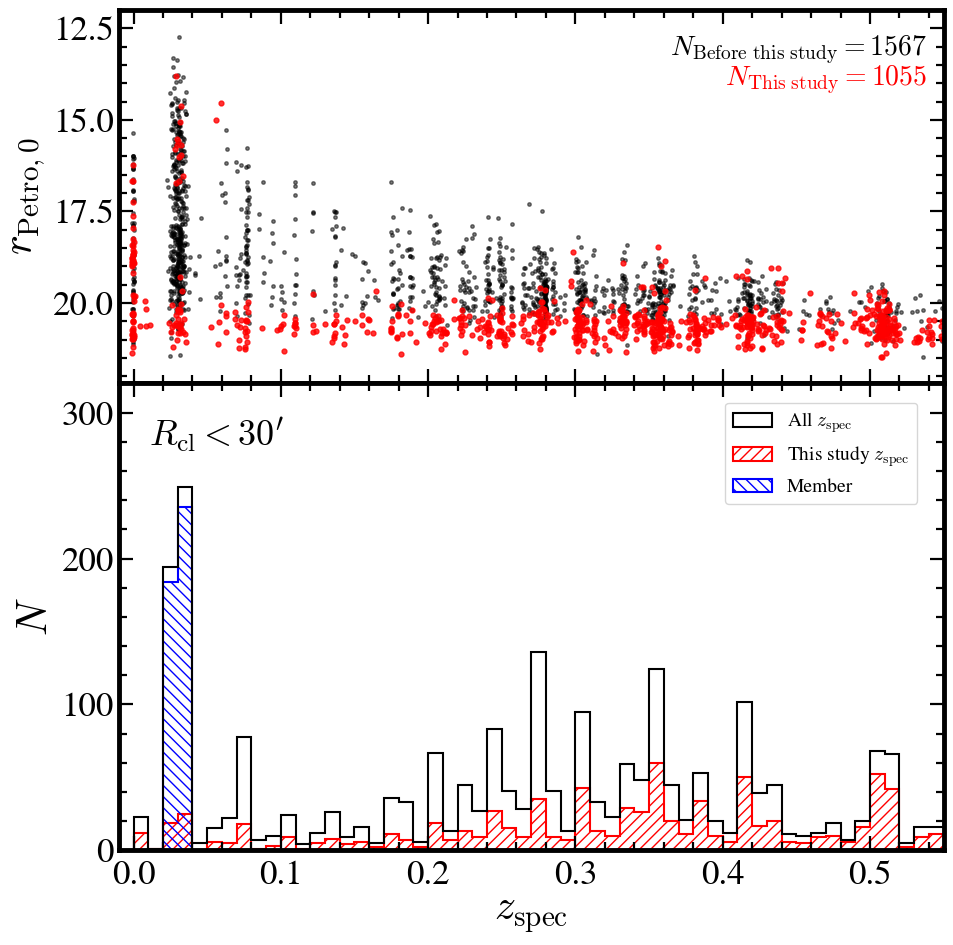

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Define bin edges from 0 to 0.6 with bin width 0.1/10
bins = np.arange(0, 0.6 + 0.1/10, 0.1/10)
df_plot = df[(df['z_tot_z'] != -9.0) & (df['p_radgal'] <= 30)]

# Create figure and subplots
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 10), gridspec_kw={'height_ratios': [0.8, 1]}
)

# Masks
mask_song = df_plot['Song2017_Flag'] == 'Y'
mask_mine = df_plot['Song2017_Flag'] == 'N'
mask_member = df_plot['member'] == 'Y'

# --- Top panel: scatter plot ---
# Previous study (song2017)
ax_top.plot(df_plot.loc[mask_song, 'z_tot_z'],
            df_plot.loc[mask_song, 'p_petromag_r_0'],
            'o', color='black', markersize=2.5, alpha=0.5)

# Mine
ax_top.plot(df_plot.loc[mask_mine, 'z_tot_z'],
            df_plot.loc[mask_mine, 'p_petromag_r_0'],
            'o', color='red', markersize=3.5, alpha=0.8)

# Text annotation with counts
N_before = mask_song.sum()
N_this = mask_mine.sum()
# Annotate sample sizes with color for 'This study'
y0 = 0.85
ax_top.text(0.98, y0,
            fr"$N_\mathrm{{Before\ this\ study}} = {N_before}$",
            transform=ax_top.transAxes, fontsize=20,
            ha='right', va='bottom')
ax_top.text(0.98, y0-0.08,
            fr"$N_\mathrm{{This\ study}} = {N_this}$",
            transform=ax_top.transAxes, fontsize=20,
            color='red', ha='right', va='bottom')


# Top panel formatting
ax_top.set_ylabel(r'$r_\mathrm{Petro,0}$', fontsize=30)
ax_top.invert_yaxis()
ax_top.set_ylim(22.2, 12)

# Add annotation
ax_bottom.annotate(r"$R_\mathrm{cl} < 30'$", xy=(0.2, 0.85), xycoords='axes fraction',
                   ha='right', va='bottom', fontsize=26)

# --- Bottom panel: histograms ---
# All z_spec
ax_bottom.hist(df_plot['z_tot_z'], bins=bins, histtype='step',
               linewidth=1.5, color='black', label='All $z_\mathrm{spec}$')

# MMT histogram
ax_bottom.hist(df_plot.loc[mask_mine, 'z_tot_z'], bins=bins, histtype='stepfilled',
               edgecolor='red', facecolor='none', hatch='///',
               linewidth=1.5, label='This study $z_\mathrm{spec}$')

# Member histogram
ax_bottom.hist(df_plot.loc[mask_member, 'z_tot_z'], bins=bins, histtype='stepfilled',
               edgecolor='blue', facecolor='none', hatch='\\\\\\',
               linewidth=1.5, label='Member')

# Labels and limits
ax_bottom.set_xlabel(r'$z_\mathrm{spec}$', fontsize=30)
ax_bottom.set_ylabel(r'$N$', fontsize=30)
ax_bottom.set_xlim(-0.01, 0.55)
ax_bottom.set_ylim(0, 320)

# Legend
ax_bottom.legend(fontsize=14, loc='upper right', bbox_to_anchor=(0.98, 0.98))

# Add minor ticks and ticks on all sides
for ax in (ax_top, ax_bottom):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.minorticks_on()

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)
plt.show()